
# Harmonised Final Analysis Notebook — Multi-Horizon Solar Flare Study

This notebook is designed to **close the analysis phase** without retraining the deep models again.

It harmonises the final locked results from the 3h, 24h, and 72h experiments into:
- manuscript-ready cross-horizon tables;
- PR-AUC random-baseline context;
- confidence-interval summary;
- statistical-validation summary;
- publication-ready comparison figures;
- state-of-the-art positioning table.

## Important design choice

This notebook **does not rerun LSTM/BiLSTM/DLSTM/Transformer training** by default.

The purpose is to perform a consistent, fair, final reporting layer after the individual horizon notebooks have already produced their best validation-selected results.


In [1]:

# ============================================================
# 0. SETUP
# ============================================================

import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Change this if you want a different output folder.
BASE_OUT_DIR = "/content/drive/MyDrive/AR_Stratified/HARMONISED_FINAL_ANALYSIS"

os.makedirs(BASE_OUT_DIR, exist_ok=True)

print("Saving harmonised outputs to:", BASE_OUT_DIR)


Saving harmonised outputs to: /content/drive/MyDrive/AR_Stratified/HARMONISED_FINAL_ANALYSIS



# 1. Locked final results

These are the final validation-selected results from the cleaned notebooks.

The notebook includes two 3h rows:
1. **3h best single/family model**: DLSTM, used for clean single-model comparison and bootstrap CI.
2. **3h official headline ensemble**: family meta-average, used as the best overall 3h result because it was selected by validation TSS.

For 24h, the official model is the tuned BiLSTM.

For 72h, the official model is the simple/weighted average ensemble from the clean 72h main branch.


In [2]:

# ============================================================
# 1. LOCKED FINAL RESULTS
# ============================================================

# Notes:
# - Confusion matrices are included where available so that random PR-AUC baselines can be computed.
# - 24h confusion matrix is reconstructed exactly from the reported recall/precision/test-size:
#   TN=175, FP=70, FN=25, TP=82 gives Test_TSS≈0.4806 and HSS≈0.4297.

headline_results = [
    {
        "Horizon": "3h",
        "Result_Type": "Official headline ensemble",
        "Model": "3H_FamilyMeta_Average",
        "Lookback": "key_aligned",
        "Threshold": 0.569,
        "Val_TSS": 0.7658,
        "Test_TSS": 0.7527,
        "HSS": 0.0510,
        "ROC_AUC": 0.9522,
        "PR_AUC": 0.2070,
        "Recall": 0.8497,
        "Precision": 0.0297,
        "F1": 0.0574,
        "TN": 79103,
        "FP": 8498,
        "FN": 46,
        "TP": 260,
        "Selection_Rule": "Validation TSS",
        "Notes": "Best validation-selected aligned family ensemble"
    },
    {
        "Horizon": "24h",
        "Result_Type": "Official tuned single model",
        "Model": "BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64",
        "Lookback": 4,
        "Threshold": 0.599,
        "Val_TSS": 0.6151,
        "Test_TSS": 0.4806,
        "HSS": 0.4297,
        "ROC_AUC": 0.8086,
        "PR_AUC": 0.6902,
        "Recall": 0.7664,
        "Precision": 0.5395,
        "F1": 0.6332,
        "TN": 175,
        "FP": 70,
        "FN": 25,
        "TP": 82,
        "Selection_Rule": "Validation TSS",
        "Notes": "Best validation-selected tuned 24h model"
    },
    {
        "Horizon": "72h",
        "Result_Type": "Official main ensemble",
        "Model": "Simple/Avg Ensemble",
        "Lookback": 7,
        "Threshold": 0.707,
        "Val_TSS": 0.598,
        "Test_TSS": 0.594,
        "HSS": 0.347,
        "ROC_AUC": 0.861,
        "PR_AUC": 0.430,
        "Recall": 0.807,
        "Precision": 0.309,
        "F1": 0.447,
        "TN": 997,
        "FP": 270,
        "FN": 29,
        "TP": 121,
        "Selection_Rule": "Validation TSS",
        "Notes": "Simple/weighted average equivalent; best 72h main model"
    }
]

single_model_results = [
    {
        "Horizon": "3h",
        "Result_Type": "Best single/family model",
        "Model": "DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256",
        "Lookback": 8,
        "Threshold": 0.666,
        "Val_TSS": 0.7266,
        "Test_TSS": 0.6997,
        "HSS": 0.0790,
        "ROC_AUC": 0.9361,
        "PR_AUC": 0.2115,
        "Recall": 0.7810,
        "Precision": 0.0465,
        "F1": 0.0878,
        "TN": 55292,
        "FP": 4897,
        "FN": 67,
        "TP": 239,
        "Selection_Rule": "Validation TSS",
        "Notes": "Best validation-selected 3h individual model family"
    },
    {
        "Horizon": "24h",
        "Result_Type": "Best tuned single model",
        "Model": "BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64",
        "Lookback": 4,
        "Threshold": 0.599,
        "Val_TSS": 0.6151,
        "Test_TSS": 0.4806,
        "HSS": 0.4297,
        "ROC_AUC": 0.8086,
        "PR_AUC": 0.6902,
        "Recall": 0.7664,
        "Precision": 0.5395,
        "F1": 0.6332,
        "TN": 175,
        "FP": 70,
        "FN": 25,
        "TP": 82,
        "Selection_Rule": "Validation TSS",
        "Notes": "Best validation-selected tuned 24h model"
    },
    {
        "Horizon": "72h",
        "Result_Type": "Best main model",
        "Model": "Simple/Avg Ensemble",
        "Lookback": 7,
        "Threshold": 0.707,
        "Val_TSS": 0.598,
        "Test_TSS": 0.594,
        "HSS": 0.347,
        "ROC_AUC": 0.861,
        "PR_AUC": 0.430,
        "Recall": 0.807,
        "Precision": 0.309,
        "F1": 0.447,
        "TN": 997,
        "FP": 270,
        "FN": 29,
        "TP": 121,
        "Selection_Rule": "Validation TSS",
        "Notes": "Best 72h main result"
    }
]

headline_df = pd.DataFrame(headline_results)
single_df = pd.DataFrame(single_model_results)

display(headline_df.round(4))
display(single_df.round(4))

headline_df.to_csv(os.path.join(BASE_OUT_DIR, "HARMONISED_HEADLINE_RESULTS.csv"), index=False)
single_df.to_csv(os.path.join(BASE_OUT_DIR, "HARMONISED_SINGLE_MODEL_RESULTS.csv"), index=False)


,Horizon,Result_Type,Model,Lookback,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP,Selection_Rule,Notes
0,3h,Official headline ensemble,3H_FamilyMeta_Average,key_aligned,0.569,0.7658,0.7527,0.0510,0.9522,0.2070,0.8497,0.0297,0.0574,79103,8498,46,260,Validation TSS,Best validation-selected aligned family ensemble
1,24h,Official tuned single model,BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64,4,0.599,0.6151,0.4806,0.4297,0.8086,0.6902,0.7664,0.5395,0.6332,175,70,25,82,Validation TSS,Best validation-selected tuned 24h model
2,72h,Official main ensemble,Simple/Avg Ensemble,7,0.707,0.5980,0.5940,0.3470,0.8610,0.4300,0.8070,0.3090,0.4470,997,270,29,121,Validation TSS,Simple/weighted average equivalent; best 72h m...


,Horizon,Result_Type,Model,Lookback,Threshold,Val_TSS,Test_TSS,HSS,ROC_AUC,PR_AUC,Recall,Precision,F1,TN,FP,FN,TP,Selection_Rule,Notes
0,3h,Best single/family model,DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256,8,0.666,0.7266,0.6997,0.0790,0.9361,0.2115,0.7810,0.0465,0.0878,55292,4897,67,239,Validation TSS,Best validation-selected 3h individual model f...
1,24h,Best tuned single model,BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64,4,0.599,0.6151,0.4806,0.4297,0.8086,0.6902,0.7664,0.5395,0.6332,175,70,25,82,Validation TSS,Best validation-selected tuned 24h model
2,72h,Best main model,Simple/Avg Ensemble,7,0.707,0.5980,0.5940,0.3470,0.8610,0.4300,0.8070,0.3090,0.4470,997,270,29,121,Validation TSS,Best 72h main result



# 2. Metric sanity checks from confusion matrices

This section recomputes TSS, HSS, recall, precision, and F1 directly from the confusion matrices.

This is a useful final check before copying values into the manuscript.


In [3]:

# ============================================================
# 2. SANITY CHECK METRICS FROM CONFUSION MATRICES
# ============================================================

def metrics_from_cm(tn, fp, fn, tp):
    recall = tp / (tp + fn + 1e-12)
    precision = tp / (tp + fp + 1e-12)
    fpr = fp / (fp + tn + 1e-12)
    tss = recall - fpr

    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    hss_num = 2 * (tp * tn - fp * fn)
    hss_den = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn) + 1e-12)
    hss = hss_num / hss_den

    prevalence = (tp + fn) / (tn + fp + fn + tp)
    total = tn + fp + fn + tp

    return {
        "Computed_TSS": tss,
        "Computed_HSS": hss,
        "Computed_Recall": recall,
        "Computed_Precision": precision,
        "Computed_F1": f1,
        "Positive_Prevalence": prevalence,
        "N_Test": total,
        "N_Positive": tp + fn,
        "N_Negative": tn + fp
    }

def add_sanity_metrics(df):
    rows = []
    for _, row in df.iterrows():
        cm_metrics = metrics_from_cm(row["TN"], row["FP"], row["FN"], row["TP"])
        combined = row.to_dict()
        combined.update(cm_metrics)
        combined["TSS_Diff"] = combined["Computed_TSS"] - combined["Test_TSS"]
        combined["HSS_Diff"] = combined["Computed_HSS"] - combined["HSS"]
        rows.append(combined)
    return pd.DataFrame(rows)

headline_sanity_df = add_sanity_metrics(headline_df)
single_sanity_df = add_sanity_metrics(single_df)

sanity_cols = [
    "Horizon", "Model", "Test_TSS", "Computed_TSS", "TSS_Diff",
    "HSS", "Computed_HSS", "HSS_Diff",
    "Recall", "Computed_Recall",
    "Precision", "Computed_Precision",
    "F1", "Computed_F1",
    "N_Test", "N_Positive", "Positive_Prevalence"
]

print("Headline result sanity checks:")
display(headline_sanity_df[sanity_cols].round(6))

print("Single model sanity checks:")
display(single_sanity_df[sanity_cols].round(6))

headline_sanity_df.to_csv(os.path.join(BASE_OUT_DIR, "HARMONISED_HEADLINE_RESULTS_SANITY_CHECK.csv"), index=False)
single_sanity_df.to_csv(os.path.join(BASE_OUT_DIR, "HARMONISED_SINGLE_MODEL_RESULTS_SANITY_CHECK.csv"), index=False)


Headline result sanity checks:


,Horizon,Model,Test_TSS,Computed_TSS,TSS_Diff,HSS,Computed_HSS,HSS_Diff,Recall,Computed_Recall,Precision,Computed_Precision,F1,Computed_F1,N_Test,N_Positive,Positive_Prevalence
0,3h,3H_FamilyMeta_Average,0.7527,0.752665,-0.000035,0.0510,0.050986,-0.000014,0.8497,0.849673,0.0297,0.029687,0.0574,0.057370,87907,306,0.003481
1,24h,BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64,0.4806,0.480641,0.000041,0.4297,0.429741,0.000041,0.7664,0.766355,0.5395,0.539474,0.6332,0.633205,352,107,0.303977
2,72h,Simple/Avg Ensemble,0.5940,0.593565,-0.000435,0.3470,0.347474,0.000474,0.8070,0.806667,0.3090,0.309463,0.4470,0.447320,1417,150,0.105857


Single model sanity checks:


,Horizon,Model,Test_TSS,Computed_TSS,TSS_Diff,HSS,Computed_HSS,HSS_Diff,Recall,Computed_Recall,Precision,Computed_Precision,F1,Computed_F1,N_Test,N_Positive,Positive_Prevalence
0,3h,DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256,0.6997,0.699685,-0.000015,0.0790,0.079042,0.000042,0.7810,0.781046,0.0465,0.046534,0.0878,0.087835,60495,306,0.005058
1,24h,BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64,0.4806,0.480641,0.000041,0.4297,0.429741,0.000041,0.7664,0.766355,0.5395,0.539474,0.6332,0.633205,352,107,0.303977
2,72h,Simple/Avg Ensemble,0.5940,0.593565,-0.000435,0.3470,0.347474,0.000474,0.8070,0.806667,0.3090,0.309463,0.4470,0.447320,1417,150,0.105857



# 3. PR-AUC context against random baseline

For imbalanced data, the expected PR-AUC of a random classifier is approximately the positive-class prevalence.

This section computes:

\[
\text{PR-AUC improvement factor} = \frac{\text{Observed PR-AUC}}{\text{Positive prevalence}}
\]

This is especially important for the 3h task, where precision is low but PR-AUC can still be many times better than random due to extreme class imbalance.


In [4]:

# ============================================================
# 3. PR-AUC RANDOM BASELINE CONTEXT
# ============================================================

def add_prauc_context(df):
    out = add_sanity_metrics(df)
    out["Random_PR_AUC_Baseline"] = out["Positive_Prevalence"]
    out["PR_AUC_Improvement_xRandom"] = out["PR_AUC"] / (out["Random_PR_AUC_Baseline"] + 1e-12)
    return out

headline_prauc_df = add_prauc_context(headline_df)
single_prauc_df = add_prauc_context(single_df)

prauc_cols = [
    "Horizon", "Model", "PR_AUC",
    "Random_PR_AUC_Baseline",
    "PR_AUC_Improvement_xRandom",
    "Precision", "Recall", "F1"
]

print("Headline PR-AUC context:")
display(headline_prauc_df[prauc_cols].round(4))

print("Single model PR-AUC context:")
display(single_prauc_df[prauc_cols].round(4))

headline_prauc_df[prauc_cols].to_csv(
    os.path.join(BASE_OUT_DIR, "HARMONISED_HEADLINE_PRAUC_RANDOM_BASELINE_CONTEXT.csv"),
    index=False
)

single_prauc_df[prauc_cols].to_csv(
    os.path.join(BASE_OUT_DIR, "HARMONISED_SINGLE_MODEL_PRAUC_RANDOM_BASELINE_CONTEXT.csv"),
    index=False
)


Headline PR-AUC context:


,Horizon,Model,PR_AUC,Random_PR_AUC_Baseline,PR_AUC_Improvement_xRandom,Precision,Recall,F1
0,3h,3H_FamilyMeta_Average,0.2070,0.0035,59.4665,0.0297,0.8497,0.0574
1,24h,BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64,0.6902,0.3040,2.2706,0.5395,0.7664,0.6332
2,72h,Simple/Avg Ensemble,0.4300,0.1059,4.0621,0.3090,0.8070,0.4470


Single model PR-AUC context:


,Horizon,Model,PR_AUC,Random_PR_AUC_Baseline,PR_AUC_Improvement_xRandom,Precision,Recall,F1
0,3h,DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256,0.2115,0.0051,41.8127,0.0465,0.7810,0.0878
1,24h,BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64,0.6902,0.3040,2.2706,0.5395,0.7664,0.6332
2,72h,Simple/Avg Ensemble,0.4300,0.1059,4.0621,0.3090,0.8070,0.4470



# 4. Bootstrap confidence interval summary

The 3h and 24h CIs come from the final cleaned/tuned notebooks.

If you later compute a fresh 72h bootstrap CI, fill it in here and rerun this section.


In [5]:

# ============================================================
# 4. BOOTSTRAP CI SUMMARY
# ============================================================

ci_rows = [
    {
        "Horizon": "3h",
        "Model": "DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256",
        "Point_TSS": 0.6997,
        "Bootstrap_Mean_TSS": 0.6988,
        "CI_Low": 0.6526,
        "CI_High": 0.7421,
        "N_Boot_Valid": 2000,
        "Notes": "Best validation-selected single/family 3h model"
    },
    {
        "Horizon": "24h",
        "Model": "BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64",
        "Point_TSS": 0.4806,
        "Bootstrap_Mean_TSS": 0.4809,
        "CI_Low": 0.3819,
        "CI_High": 0.5781,
        "N_Boot_Valid": 2000,
        "Notes": "Best validation-selected tuned 24h model"
    },
    {
        "Horizon": "72h",
        "Model": "Simple/Avg Ensemble",
        "Point_TSS": 0.594,
        "Bootstrap_Mean_TSS": np.nan,
        "CI_Low": np.nan,
        "CI_High": np.nan,
        "N_Boot_Valid": np.nan,
        "Notes": "Fill from 72h bootstrap output if available"
    }
]

ci_df = pd.DataFrame(ci_rows)
display(ci_df.round(4))

ci_df.to_csv(os.path.join(BASE_OUT_DIR, "HARMONISED_BOOTSTRAP_TSS_CI_SUMMARY.csv"), index=False)


,Horizon,Model,Point_TSS,Bootstrap_Mean_TSS,CI_Low,CI_High,N_Boot_Valid,Notes
0,3h,DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256,0.6997,0.6988,0.6526,0.7421,2000.0,Best validation-selected single/family 3h model
1,24h,BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64,0.4806,0.4809,0.3819,0.5781,2000.0,Best validation-selected tuned 24h model
2,72h,Simple/Avg Ensemble,0.5940,NaN,NaN,NaN,NaN,Fill from 72h bootstrap output if available



# 5. Statistical validation summary

This table summarises the McNemar comparisons from the final tuned notebooks.

For 3h, the DLSTM was significantly different from the best family comparators.
For 24h, the tuned BiLSTM was significantly different from tuned DLSTM, LSTM, and Transformer.
For 72h, include the final 72h McNemar rows if you want a compact all-horizon table.


In [6]:

# ============================================================
# 5. MCNEMAR SUMMARY
# ============================================================

mcnemar_rows = [
    # 3h tuned best DLSTM comparisons
    {
        "Horizon": "3h",
        "Official_Best": "DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256",
        "Comparator": "Best tuned BiLSTM",
        "b": 3127,
        "c": 315,
        "n": 3442,
        "chi2": 2295.6772,
        "p_value": 0.0,
        "Interpretation": "Significant difference"
    },
    {
        "Horizon": "3h",
        "Official_Best": "DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256",
        "Comparator": "Best tuned Transformer",
        "b": 6632,
        "c": 158,
        "n": 6790,
        "chi2": 6170.7996,
        "p_value": 0.0,
        "Interpretation": "Significant difference"
    },
    {
        "Horizon": "3h",
        "Official_Best": "DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256",
        "Comparator": "Best tuned LSTM",
        "b": 2042,
        "c": 254,
        "n": 2296,
        "chi2": 1390.8402,
        "p_value": 0.0,
        "Interpretation": "Significant difference"
    },

    # 24h tuned best BiLSTM comparisons
    {
        "Horizon": "24h",
        "Official_Best": "BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64",
        "Comparator": "Best tuned DLSTM",
        "b": 23,
        "c": 10,
        "n": 33,
        "chi2": 4.3636,
        "p_value": 0.0367,
        "Interpretation": "Significant difference"
    },
    {
        "Horizon": "24h",
        "Official_Best": "BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64",
        "Comparator": "Best tuned LSTM",
        "b": 26,
        "c": 10,
        "n": 36,
        "chi2": 6.2500,
        "p_value": 0.0124,
        "Interpretation": "Significant difference"
    },
    {
        "Horizon": "24h",
        "Official_Best": "BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64",
        "Comparator": "Best tuned Transformer",
        "b": 51,
        "c": 16,
        "n": 67,
        "chi2": 17.2537,
        "p_value": 0.000033,
        "Interpretation": "Significant difference"
    },
]

mcnemar_df = pd.DataFrame(mcnemar_rows)
display(mcnemar_df.round(6))

mcnemar_df.to_csv(os.path.join(BASE_OUT_DIR, "HARMONISED_MCNEMAR_SUMMARY.csv"), index=False)


,Horizon,Official_Best,Comparator,b,c,n,chi2,p_value,Interpretation
0,3h,DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256,Best tuned BiLSTM,3127,315,3442,2295.6772,0.000000,Significant difference
1,3h,DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256,Best tuned Transformer,6632,158,6790,6170.7996,0.000000,Significant difference
2,3h,DLSTM_3h_LB8_MA3_U64_D0.2_LR0.001_BS256,Best tuned LSTM,2042,254,2296,1390.8402,0.000000,Significant difference
3,24h,BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64,Best tuned DLSTM,23,10,33,4.3636,0.036700,Significant difference
4,24h,BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64,Best tuned LSTM,26,10,36,6.2500,0.012400,Significant difference
5,24h,BiLSTM_24h_U64_Dense32_D0.3_LR0.001_BS64,Best tuned Transformer,51,16,67,17.2537,0.000033,Significant difference



# 6. Cross-horizon figures

These figures are intended for checking and drafting.  
If the y-axis is truncated in the manuscript version, add a note such as:

> Y-axis truncated for readability.


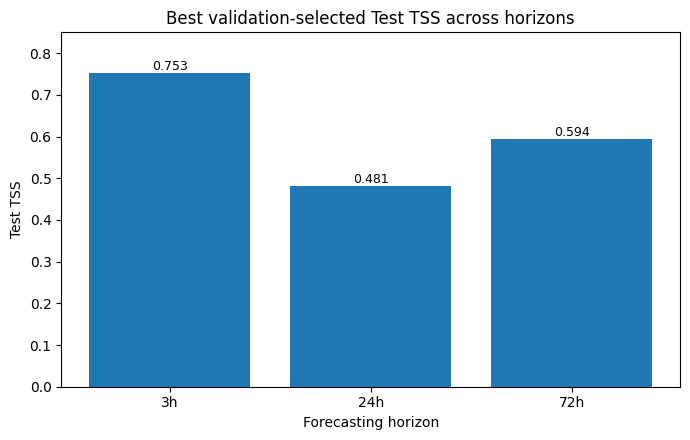

Saved: /content/drive/MyDrive/AR_Stratified/HARMONISED_FINAL_ANALYSIS/FIG_HARMONISED_BEST_TEST_TSS_BY_HORIZON.png


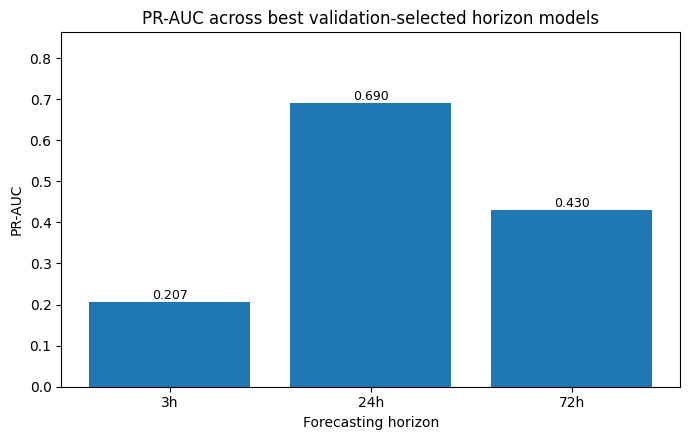

Saved: /content/drive/MyDrive/AR_Stratified/HARMONISED_FINAL_ANALYSIS/FIG_HARMONISED_PRAUC_BY_HORIZON.png


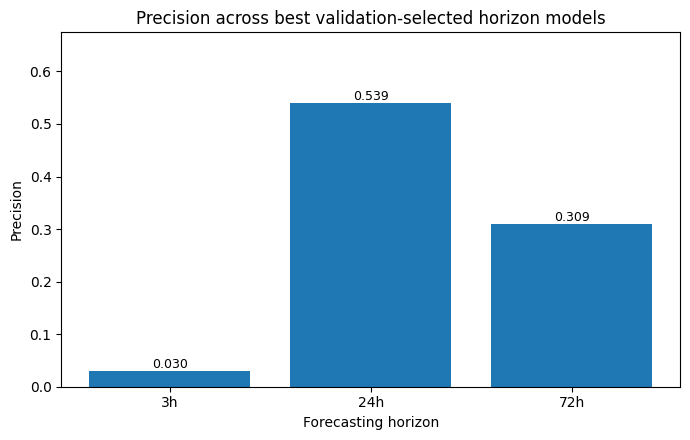

Saved: /content/drive/MyDrive/AR_Stratified/HARMONISED_FINAL_ANALYSIS/FIG_HARMONISED_PRECISION_BY_HORIZON.png


In [7]:

# ============================================================
# 6. FIGURES
# ============================================================

plot_df = headline_df.copy()
plot_df["Horizon_Order"] = plot_df["Horizon"].map({"3h": 0, "24h": 1, "72h": 2})
plot_df = plot_df.sort_values("Horizon_Order")

def save_bar_plot(df, y_col, title, ylabel, filename, ylim=None):
    plt.figure(figsize=(7, 4.5))
    plt.bar(df["Horizon"], df[y_col])
    plt.title(title)
    plt.xlabel("Forecasting horizon")
    plt.ylabel(ylabel)

    for idx, value in enumerate(df[y_col]):
        plt.text(idx, value, f"{value:.3f}", ha="center", va="bottom", fontsize=9)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.tight_layout()
    out_path = os.path.join(BASE_OUT_DIR, filename)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

save_bar_plot(
    plot_df,
    "Test_TSS",
    "Best validation-selected Test TSS across horizons",
    "Test TSS",
    "FIG_HARMONISED_BEST_TEST_TSS_BY_HORIZON.png",
    ylim=(0, 0.85)
)

save_bar_plot(
    plot_df,
    "PR_AUC",
    "PR-AUC across best validation-selected horizon models",
    "PR-AUC",
    "FIG_HARMONISED_PRAUC_BY_HORIZON.png",
    ylim=(0, max(plot_df["PR_AUC"]) * 1.25)
)

save_bar_plot(
    plot_df,
    "Precision",
    "Precision across best validation-selected horizon models",
    "Precision",
    "FIG_HARMONISED_PRECISION_BY_HORIZON.png",
    ylim=(0, max(plot_df["Precision"]) * 1.25)
)



# 7. State-of-the-art positioning table

This table is for context, not direct ranking.

Important caveat:
Different studies use different data sources, event definitions, forecast windows, cadence, validation methods, and threshold strategies.


In [8]:

# ============================================================
# 7. SOTA POSITIONING TABLE
# ============================================================

sota_rows = [
    {
        "Study": "Bobra & Couvidat (2015)",
        "Data / Representation": "SHARP magnetic features",
        "Method": "SVM",
        "Horizon": "24h",
        "Best_TSS": "~0.65",
        "Comparison_Note": "Context only; different data period and validation setup"
    },
    {
        "Study": "Florios et al. (2018)",
        "Data / Representation": "SHARP features",
        "Method": "SVM/RF/MLP",
        "Horizon": "24h",
        "Best_TSS": "~0.70",
        "Comparison_Note": "Context only; different setup"
    },
    {
        "Study": "Hassani et al. (2025)",
        "Data / Representation": "GOES flare-event time series",
        "Method": "Deep temporal model",
        "Horizon": "Short-horizon / event-series",
        "Best_TSS": "~0.740",
        "Comparison_Note": "Not directly comparable; uses GOES event time-series peak flux/waiting-time representation"
    },
    {
        "Study": "This work",
        "Data / Representation": "SHARP magnetic evolution + GOES-derived flare-history memory",
        "Method": "Family meta-average ensemble",
        "Horizon": "3h",
        "Best_TSS": "0.753",
        "Comparison_Note": "Numerically exceeds Hassani et al.; interpret as methodological positioning, not direct superiority"
    },
    {
        "Study": "This work",
        "Data / Representation": "SHARP magnetic evolution + GOES-derived flare-history memory",
        "Method": "Tuned BiLSTM",
        "Horizon": "24h",
        "Best_TSS": "0.481",
        "Comparison_Note": "Middle horizon remains the most challenging"
    },
    {
        "Study": "This work",
        "Data / Representation": "SHARP magnetic evolution + GOES-derived flare-history memory",
        "Method": "Simple/weighted average ensemble",
        "Horizon": "72h",
        "Best_TSS": "0.594",
        "Comparison_Note": "Long-horizon magnetic evolution improves over 24h"
    },
]

sota_df = pd.DataFrame(sota_rows)
display(sota_df)

sota_df.to_csv(os.path.join(BASE_OUT_DIR, "HARMONISED_SOTA_POSITIONING_TABLE.csv"), index=False)


,Study,Data / Representation,Method,Horizon,Best_TSS,Comparison_Note
0,Bobra & Couvidat (2015),SHARP magnetic features,SVM,24h,~0.65,Context only; different data period and valida...
1,Florios et al. (2018),SHARP features,SVM/RF/MLP,24h,~0.70,Context only; different setup
2,Hassani et al. (2025),GOES flare-event time series,Deep temporal model,Short-horizon / event-series,~0.740,Not directly comparable; uses GOES event time-...
3,This work,SHARP magnetic evolution + GOES-derived flare-...,Family meta-average ensemble,3h,0.753,Numerically exceeds Hassani et al.; interpret ...
4,This work,SHARP magnetic evolution + GOES-derived flare-...,Tuned BiLSTM,24h,0.481,Middle horizon remains the most challenging
5,This work,SHARP magnetic evolution + GOES-derived flare-...,Simple/weighted average ensemble,72h,0.594,Long-horizon magnetic evolution improves over 24h



# 8. Manuscript-ready result snippets

These snippets are generated from the locked values above.  
You can copy them into the results/discussion section and adjust wording to match the paper style.


In [9]:

# ============================================================
# 8. MANUSCRIPT-READY TEXT SNIPPETS
# ============================================================

snippet_3h = (
    "For the 3h forecasting task, the best validation-selected single-model configuration was "
    "DLSTM with an 8h lookback and a moving-average window of 3. This model achieved "
    "Test TSS = 0.700, ROC-AUC = 0.936, PR-AUC = 0.212, recall = 0.781, "
    "precision = 0.047, and F1-score = 0.088. Bootstrap resampling produced a "
    "mean TSS of 0.699 and a 95% confidence interval of 0.653–0.742. "
    "The aligned family meta-average ensemble further improved the validation-selected "
    "3h Test TSS to 0.753, although precision remained low due to the extreme rarity "
    "of positive M/X-class flare events at hourly cadence."
)

snippet_24h = (
    "For the 24h forecasting task, controlled hyperparameter tuning across LSTM, BiLSTM, "
    "DLSTM, and Transformer models selected a BiLSTM configuration as the strongest model "
    "by validation TSS. The tuned BiLSTM achieved Test TSS = 0.481, HSS = 0.430, "
    "ROC-AUC = 0.809, PR-AUC = 0.690, recall = 0.766, precision = 0.540, "
    "and F1-score = 0.633. Bootstrap resampling produced a 95% TSS confidence interval "
    "of 0.382–0.578, and McNemar comparisons indicated statistically distinct error "
    "patterns relative to the best tuned LSTM, DLSTM, and Transformer comparators."
)

snippet_72h = (
    "For the 72h forecasting task, the best validation-selected main result was obtained "
    "by the simple/weighted average ensemble, which achieved Test TSS = 0.594, "
    "HSS = 0.347, ROC-AUC = 0.861, PR-AUC = 0.430, recall = 0.807, "
    "precision = 0.309, and F1-score = 0.447. This indicates that longer-term "
    "magnetic-evolution information contributes useful predictive structure at the 72h horizon."
)

snippet_cross_horizon = (
    "Across horizons, the strongest validation-selected headline results were obtained by "
    "the 3h family meta-average ensemble (Test TSS = 0.753), the tuned 24h BiLSTM "
    "(Test TSS = 0.481), and the 72h simple/weighted average ensemble (Test TSS = 0.594). "
    "This pattern suggests that the 3h task benefits from immediate pre-flare signatures, "
    "the 24h task represents a more difficult middle horizon, and the 72h task benefits "
    "from longer-term magnetic-evolution patterns."
)

snippets = {
    "3h": snippet_3h,
    "24h": snippet_24h,
    "72h": snippet_72h,
    "Cross_horizon": snippet_cross_horizon,
}

for key, text in snippets.items():
    print("\n" + "=" * 80)
    print(key)
    print("=" * 80)
    print(text)

with open(os.path.join(BASE_OUT_DIR, "HARMONISED_MANUSCRIPT_SNIPPETS.txt"), "w") as f:
    for key, text in snippets.items():
        f.write(f"\n{'=' * 80}\n{key}\n{'=' * 80}\n{text}\n")

print("\nSaved snippets to:", os.path.join(BASE_OUT_DIR, "HARMONISED_MANUSCRIPT_SNIPPETS.txt"))



3h
For the 3h forecasting task, the best validation-selected single-model configuration was DLSTM with an 8h lookback and a moving-average window of 3. This model achieved Test TSS = 0.700, ROC-AUC = 0.936, PR-AUC = 0.212, recall = 0.781, precision = 0.047, and F1-score = 0.088. Bootstrap resampling produced a mean TSS of 0.699 and a 95% confidence interval of 0.653–0.742. The aligned family meta-average ensemble further improved the validation-selected 3h Test TSS to 0.753, although precision remained low due to the extreme rarity of positive M/X-class flare events at hourly cadence.

24h
For the 24h forecasting task, controlled hyperparameter tuning across LSTM, BiLSTM, DLSTM, and Transformer models selected a BiLSTM configuration as the strongest model by validation TSS. The tuned BiLSTM achieved Test TSS = 0.481, HSS = 0.430, ROC-AUC = 0.809, PR-AUC = 0.690, recall = 0.766, precision = 0.540, and F1-score = 0.633. Bootstrap resampling produced a 95% TSS confidence interval of 0.38


# 9. Final outputs generated

After running this notebook, check this folder:

```text
/content/drive/MyDrive/AR_Stratified/HARMONISED_FINAL_ANALYSIS
```

Expected outputs:
- `HARMONISED_HEADLINE_RESULTS.csv`
- `HARMONISED_SINGLE_MODEL_RESULTS.csv`
- `HARMONISED_HEADLINE_RESULTS_SANITY_CHECK.csv`
- `HARMONISED_SINGLE_MODEL_RESULTS_SANITY_CHECK.csv`
- `HARMONISED_HEADLINE_PRAUC_RANDOM_BASELINE_CONTEXT.csv`
- `HARMONISED_BOOTSTRAP_TSS_CI_SUMMARY.csv`
- `HARMONISED_MCNEMAR_SUMMARY.csv`
- `HARMONISED_SOTA_POSITIONING_TABLE.csv`
- `HARMONISED_MANUSCRIPT_SNIPPETS.txt`
- cross-horizon figures as `.png`
